Confusion Matrix:

[[708 333]
 [640 319]]


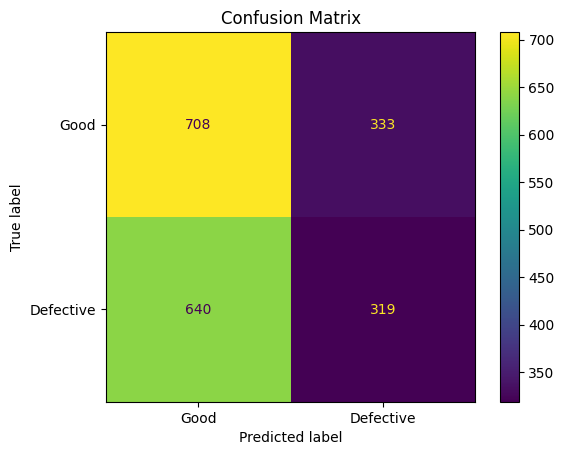

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("Manufacturing_dataset.csv")

df['Machine Mode'] = [
    'Eco',
    'Standard',
    'High-Speed',
    'Eco',
    'Standard',
    'High-Speed',
    'Eco',
    'Standard',
    'High-Speed',
    'Eco'
] * (len(df) // 10)

df = pd.get_dummies(
    df,
    columns=['Machine Mode'],
    drop_first=True
)

df['Defective'] = (df['Production Quality Score'] < 8.5).astype(int)

X = df[[
    'Machine Speed (RPM)',
    'Vibration Level (mm/s)',
    'Energy Consumption (kWh)',
    'Machine Mode_High-Speed',
    'Machine Mode_Standard'
]]

y = df['Defective']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train , y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good", "Defective"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()